# Dynamical Systems with TVBO: A Spring-Mass Example

Marius Pille (Berlin Institute of Health at Charité University
Medicine)  
Leon Martin (Berlin Institute of Health at Charité University
Medicine)  
Leon Stefanovski (Charité University Medicine Berlin)

In [1]:
import bsplot
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown

from tvbo import Dynamics, SimulationExperiment
from tvbo.datamodel.schema import Exploration, ExplorationAxis

bsplot.style.use("tvbo")

# Dynamical Systems

This notebook is the static companion to the workshop slides. The slides
show the same concepts visually; here we make them explicit in TVBO
code.

The workshop starts from the generic state-evolution equation

$$
dS_i = \left[f_d(S_i, \theta^d, C_i, I_i)\right]dt + g(S_i, \theta^g)\,dW_i.
$$

Here we remove everything except deterministic local dynamics: one
system, no coupling, no external input, and no noise. That leaves the
core object that appears throughout TVBO: a dynamical system with state
variables, parameters, initial conditions, and equations of motion.

## Learning Path

1.  Specify a dynamical system as a TVBO `Dynamics` object.
2.  Run it directly with `.run()` for quick local analysis.
3.  Put it in a `SimulationExperiment` and run it with `tvboptim`.
4.  Read results through named dimensions.
5.  Compare initial conditions as trajectories in the same flow.
6.  Use phase space to see the geometry of the dynamics.
7.  Vary parameters declaratively with `Exploration`.
8.  Add damping and load terms to move from a toy model toward realism.

## From a Second-Order Equation to TVBO

A mass $m$ attached to a spring with stiffness $k$ satisfies

$$
m\ddot{x} = -kx.
$$

Numerical ODE solvers work with first-order systems, so we introduce
velocity $v = \dot{x}$:

$$
\dot{x} = v, \qquad \dot{v} = -\frac{k}{m}x.
$$

In TVBO, we write this directly as metadata: state variables, equations,
parameters, units, and initial values.

In [2]:
spring = Dynamics(
    name="SpringMass",
    description="Undamped spring-mass oscillator in first-order form.",
    state_variables={
        "x": {
            "description": "Displacement from equilibrium",
            "unit": "m",
            "equation": {"rhs": "v"},
            "initial_value": 2.0,
        },
        "v": {
            "description": "Velocity",
            "unit": "m_per_s",
            "equation": {"rhs": "-(k/m) * x"},
            "initial_value": 0.0,
        },
    },
    parameters={
        "k": {
            "description": "Spring stiffness",
            "unit": "N_per_m",
            "value": 0.0001,
        },
        "m": {
            "description": "Mass",
            "unit": "kg",
            "value": 1.0,
        },
    },
)

Markdown(spring.render("markdown"))

## Run the Dynamics Directly

For a single local system, `Dynamics.run()` is the shortest route from
equations to a simulated trajectory.

In [3]:
spring_timeseries = spring.run(duration=900.0, dt=1.0)
spring_timeseries

TimeSeries
├── time: f64[900](numpy)
├── data: f64[900,2,1,1](numpy)
├── labels_dimensions
│   └── State Variable
│       ├── [0]: "x"
│       └── [1]: "v"
├── title: "TimeSeries"
├── network: NoneType
├── sample_period: 1.0
├── dt: 1.0
├── sample_period_unit: "ms"
├── units
│   ├── time: "ms"
│   ├── state: NoneType
│   ├── region: NoneType
│   └── mode: NoneType
└── labels_ordering
    ├── [0]: "Time"
    ├── [1]: "State Variable"
    ├── [2]: "Space"
    └── [3]: "Mode"

TVBO objects also know how to plot themselves. A quick state-variable
plot does not need custom notebook helper functions.

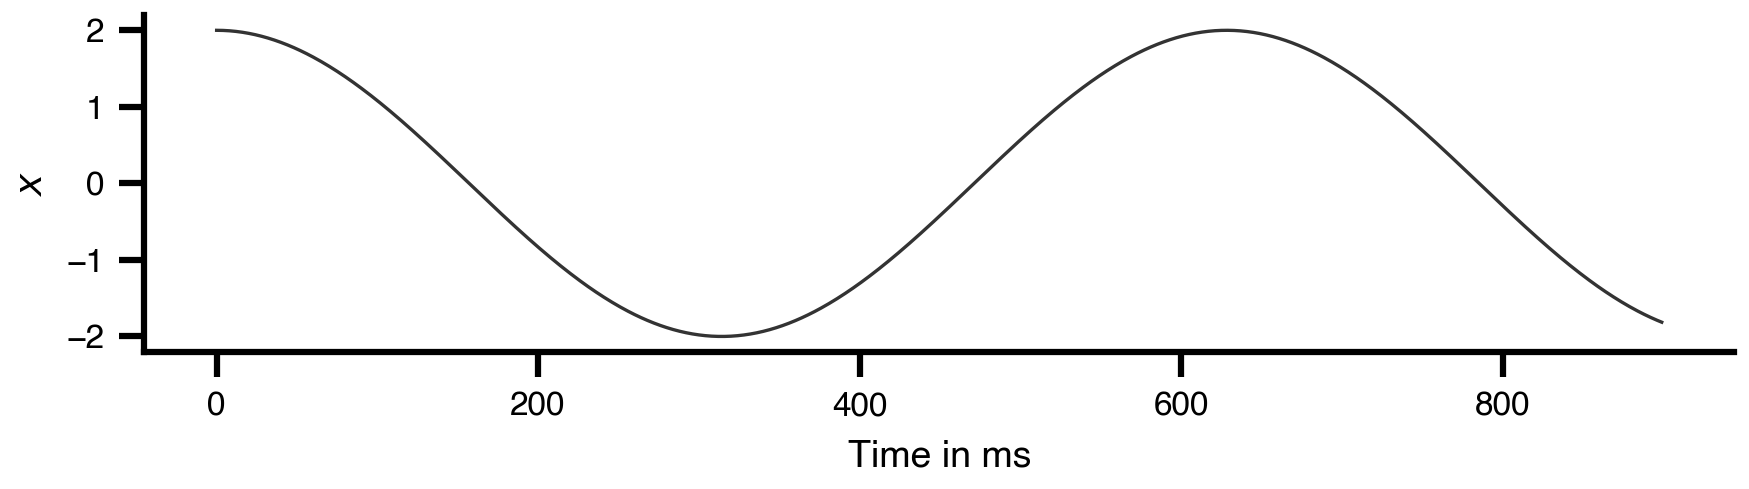

In [4]:
spring.plot("x", kind="timeseries", duration=900.0, dt=1.0)

## Run a Simulation Experiment

For the workshop workflow we usually wrap the model in a
`SimulationExperiment`. The model still describes the equations; the
experiment describes how to run them.

In [5]:
experiment = SimulationExperiment(dynamics=spring)
experiment.integration.duration = 900.0
experiment.integration.step_size = 1.0

result = experiment.run("tvboptim")
result.integration.data


STEP 1: Running simulation...
  Simulation period: 900.0 ms, dt: 1.0 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.

<xarray.DataArray (time: 900, variable: 2)> Size: 14kB
array([[ 1.99990000e+00, -2.00000000e-04],
 [ 1.99960001e+00, -3.99980000e-04],
 [ 1.99910004e+00, -5.99920002e-04],
 ...,
 [-1.80554324e+00, -8.60245663e-03],
 [-1.81405542e+00, -8.42147219e-03],
 [-1.82238619e+00, -8.23964557e-03]], shape=(900, 2))
Coordinates:
 * time (time) float64 7kB 1.0 2.0 3.0 4.0 5.0 ... 897.0 898.0 899.0 900.0
 * variable (variable) <U1 8B 'x' 'v' xarray.DataArray time : 900 variable : 2 2.0 -0.0002 2.0 -0.0004 1.999 ... -1.814 -0.008421 -1.822 -0.00824 array([[ 1.99990000e+00, -2.00000000e-04],
 [ 1.99960001e+00, -3.99980000e-04],
 [ 1.99910004e+00, -5.99920002e-04],
 ...,
 [-1.80554324e+00, -8.60245663e-03],
 [-1.81405542e+00, -8.42147219e-03],
 [-1.82238619e+00, -8.23964557e-03]], shape=(900, 2)) Coordinates: (2) time (time) float64 1.0 2.0 3.0 ... 898.0 899.0 900.0 array([ 1., 2., 3., ..., 898., 899., 900.], shape=(900,)) variable (variable) <U1 'x' 'v' array(['x', 'v'], dtype='<U1')

The result mirrors the experiment structure. The main simulation output
is `result.integration.data`, an xarray `DataArray` with named
coordinates such as `time` and `variable`.

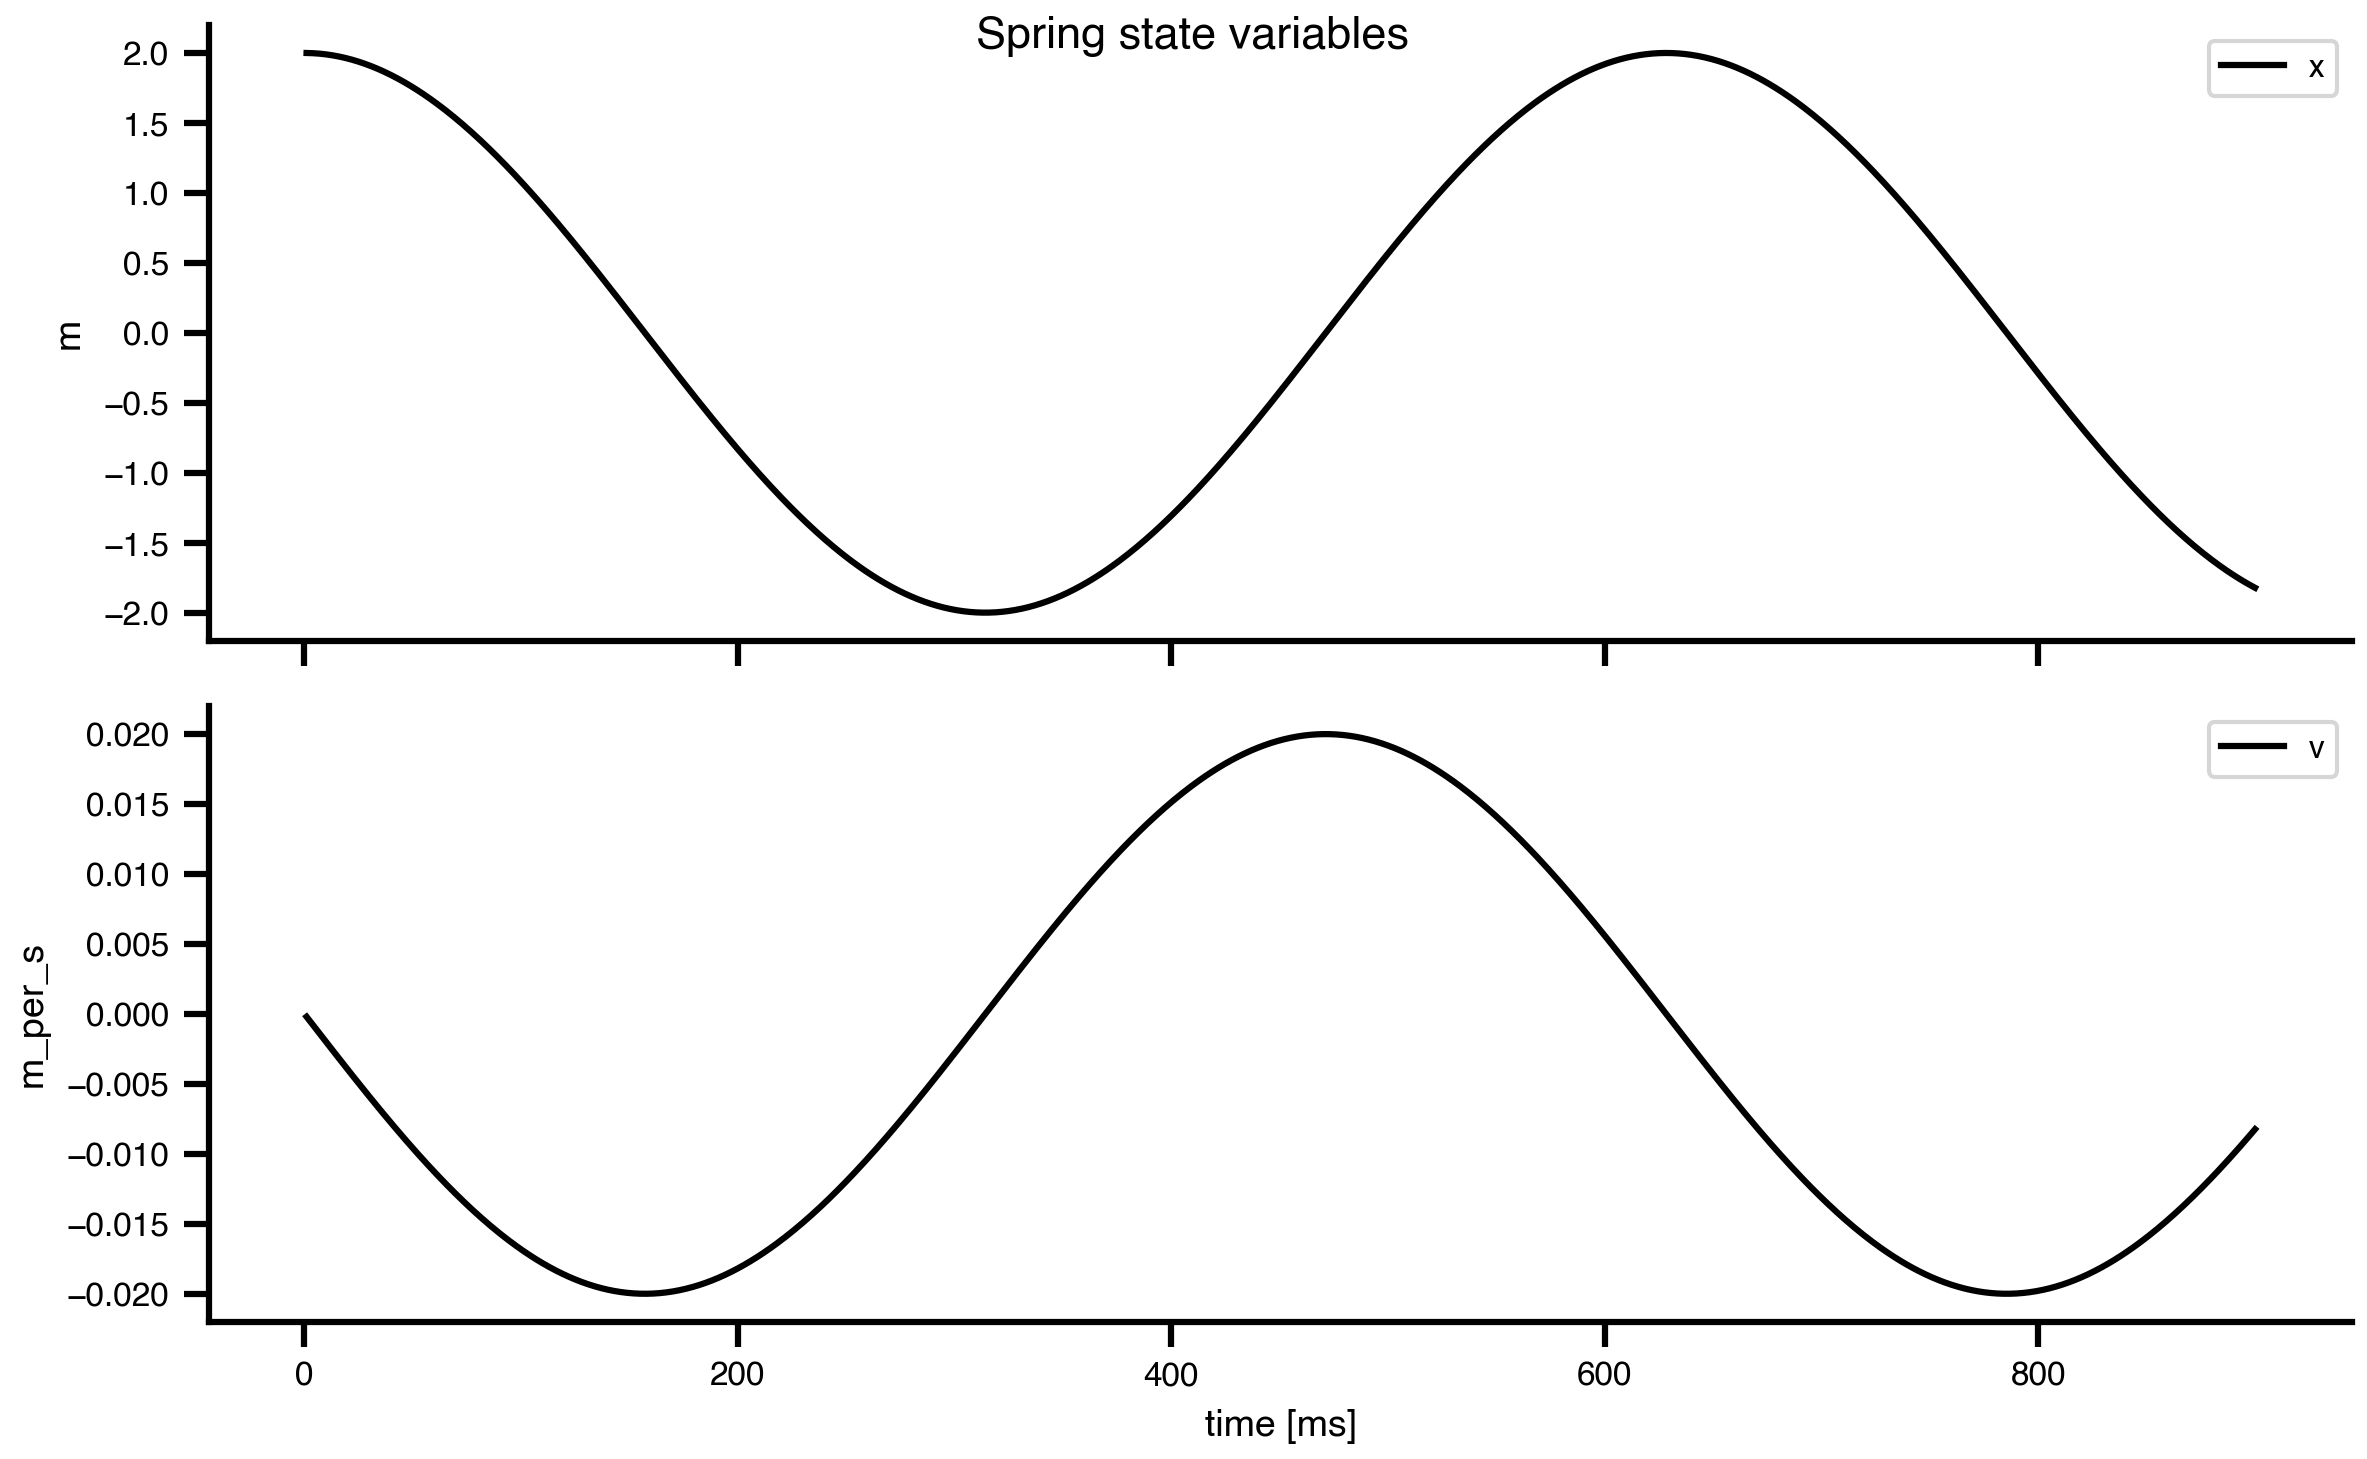

In [6]:
fig = result.integration.plot()
fig.suptitle("Spring state variables")
fig

Named dimensions make the analysis explicit. For example, select the
displacement variable by name rather than by positional index.

In [7]:
x = result.integration.data.sel(variable="x")
v = result.integration.data.sel(variable="v")

x.attrs["description"] = "Displacement from equilibrium"
v.attrs["description"] = "Velocity"

float(x.max() - x.min())

## Initial Conditions: Same Flow, Different Trajectories

Initial conditions choose where a trajectory begins. They do not change
the vector field. This distinction matters later for neural models:
changing a state variable’s initial value is not the same as changing a
physiological parameter.

For the undamped spring, larger initial displacement gives a
larger-amplitude orbit, but the frequency remains

$$
\omega = \sqrt{\frac{k}{m}}.
$$

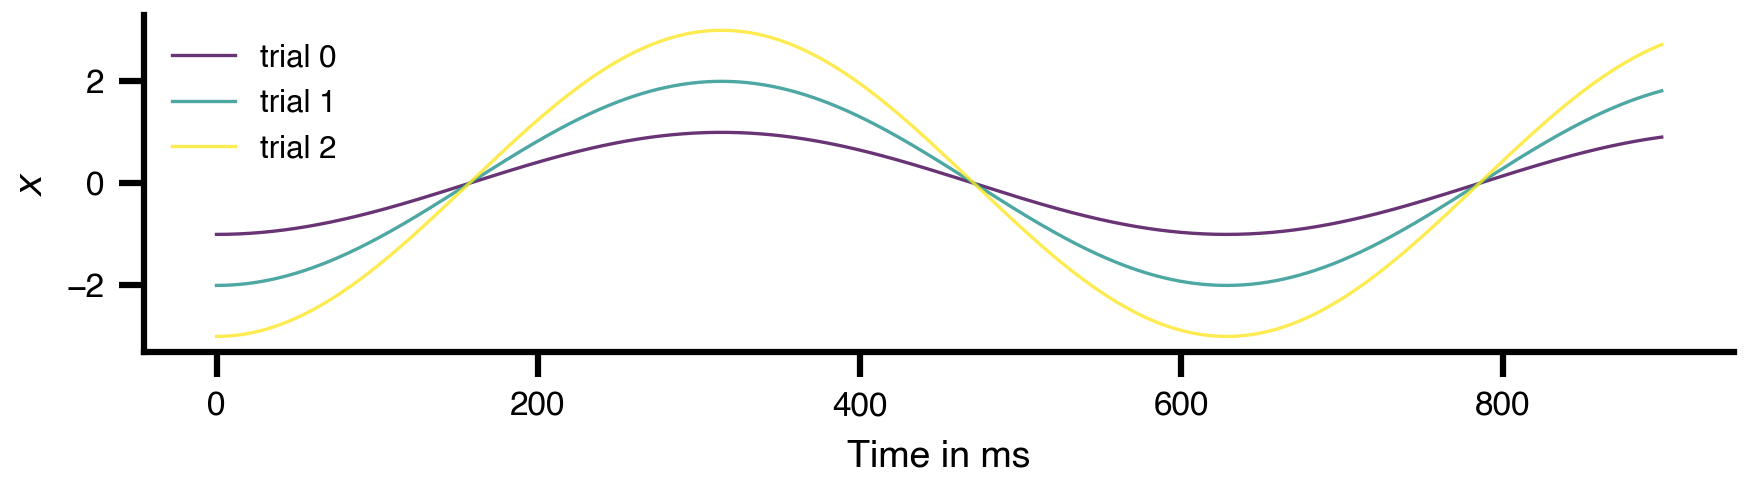

In [8]:
initial_conditions = np.array([
    [-1.0, 0.0],
    [-2.0, 0.0],
    [-3.0, 0.0],
])

spring.plot(
    "x",
    kind="timeseries",
    duration=900.0,
    dt=1.0,
    n_trials=len(initial_conditions),
    u_0=initial_conditions,
    cmap="viridis",
)

This is still the same `spring` object. Only the starting state changes.

## Phase Space: The Geometry of the Flow

A time series shows one coordinate as a function of time. A phase
portrait shows the full state $(x, v)$. This is the geometry-first view
used in nonlinear dynamics and in phase-plane neuroscience.

For the undamped spring, the trajectories are closed loops because
energy is conserved. The vector field is shared by every trajectory;
only the initial condition changes.

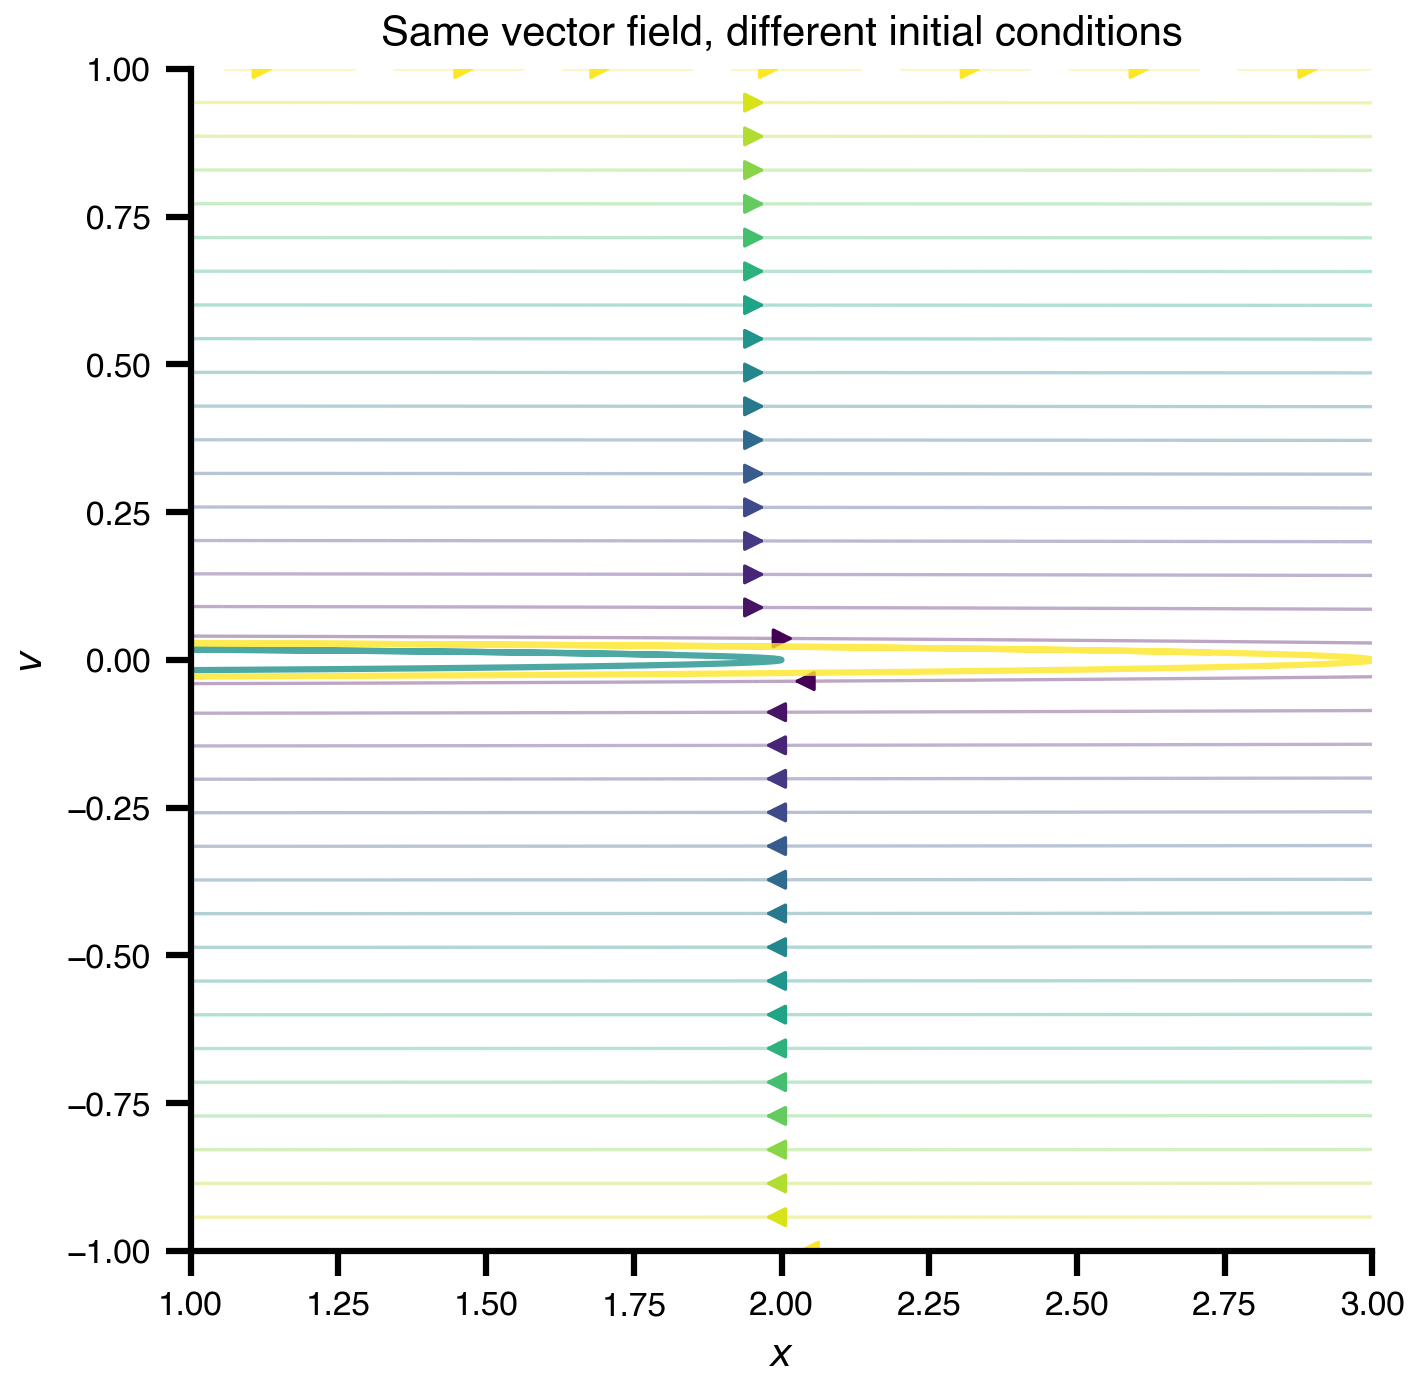

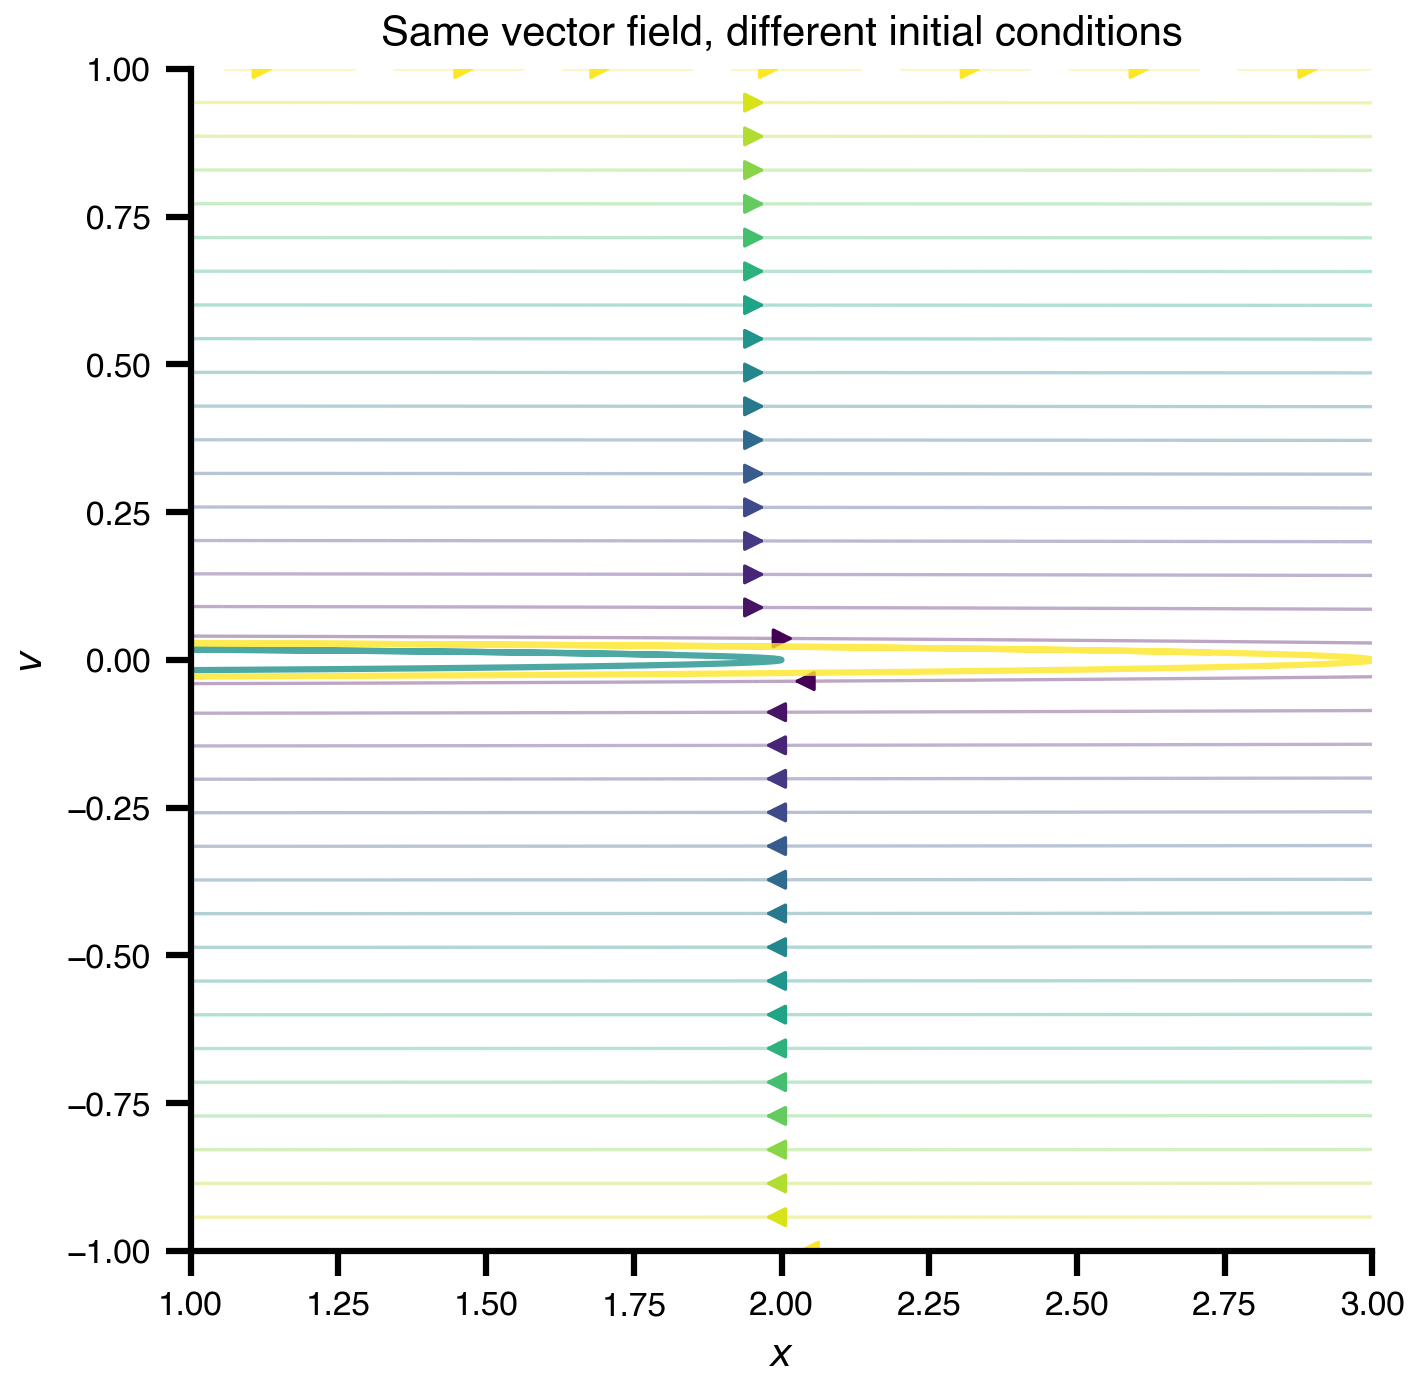

In [9]:
fig, ax = plt.subplots(figsize=(5.2, 4.8))

spring.plot("x", "v", kind="vectorfield", ax=ax, alpha=0.35, grid_n=24, stream=True)
spring.plot(
    "x",
    "v",
    kind="phase",
    ax=ax,
    duration=900.0,
    dt=1.0,
    n_trials=len(initial_conditions),
    u_0=initial_conditions,
    cmap="viridis",
    lw=1.5,
)

ax.set_title("Same vector field, different initial conditions")
fig.tight_layout()
fig

TVBO can also draw the phase plane directly, including vector field,
nullclines, fixed points, and sample trajectories.

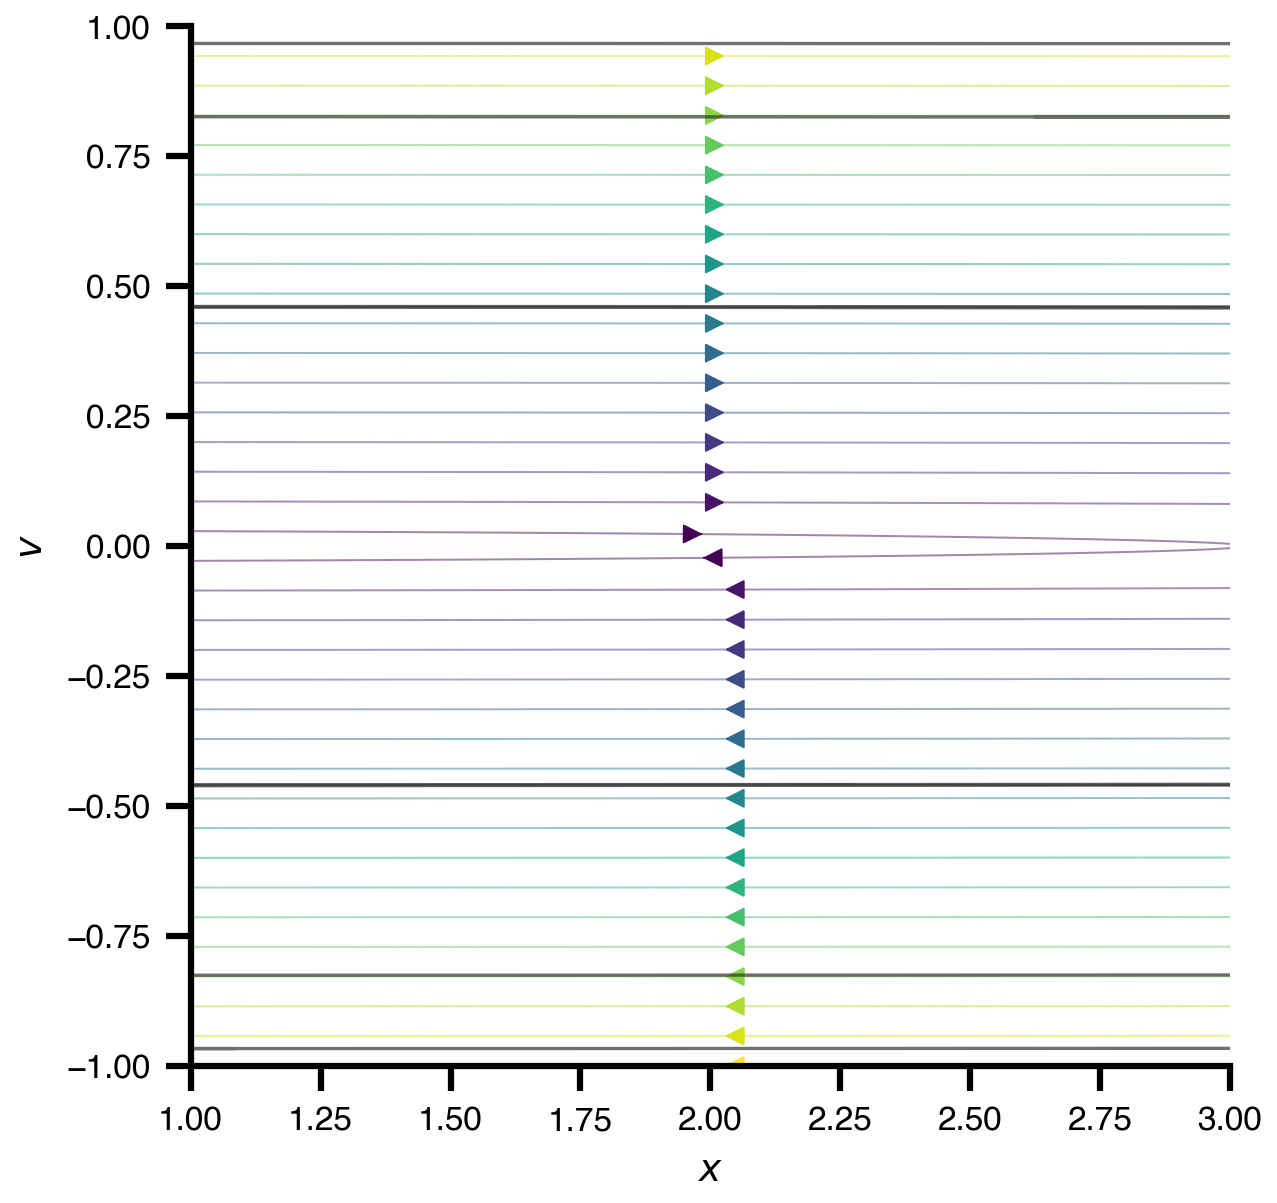

In [10]:
spring.plot(
    "x",
    "v",
    kind="phaseplane",
    duration=900.0,
    dt=1.0,
    n_trajectories=4,
    show_nullclines=False,
)

## Parameters: Changing the System Itself

Parameters are different from initial conditions. Initial conditions
choose where a trajectory begins; parameters reshape the vector field.

Here we vary the mass $m$ while keeping $k$, $x_0$, and $v_0$ fixed.
Heavier mass means more inertia, so the oscillation is slower.


STEP 1: Running simulation...
  Simulation period: 1200.0 ms, dt: 1.0 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > mass_sweep
  Explorations complete.

Experiment complete.

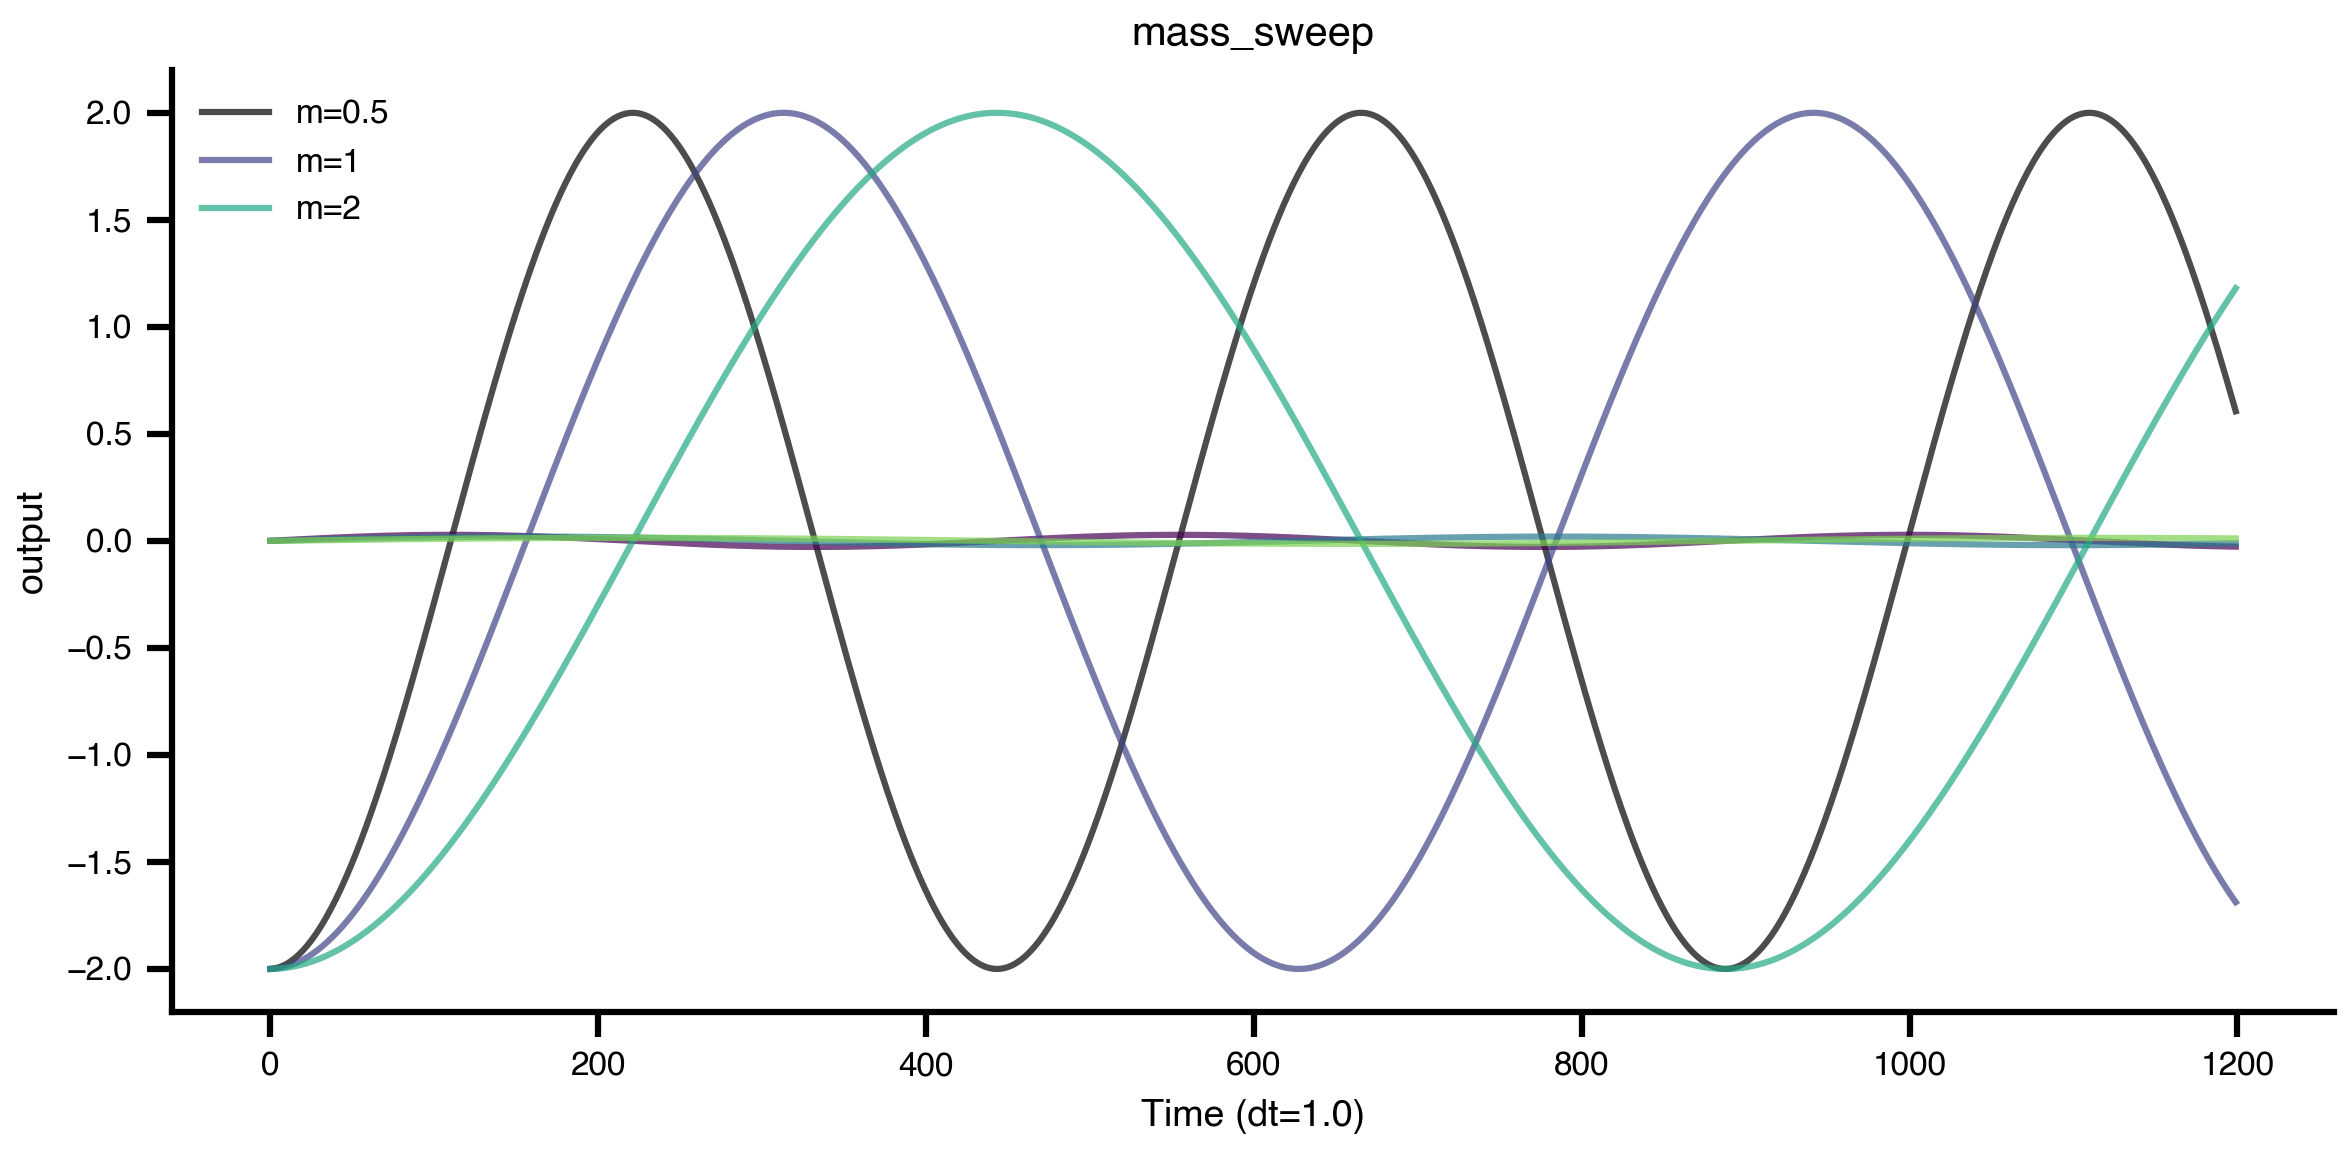

In [11]:
mass_experiment = SimulationExperiment(dynamics=spring)
mass_experiment.integration.duration = 1200.0
mass_experiment.integration.step_size = 1.0

mass_experiment.dynamics.state_variables["x"].initial_value = -2.0
mass_experiment.dynamics.state_variables["v"].initial_value = 0.0

mass_experiment.explorations["mass_sweep"] = Exploration(
    name="mass_sweep",
    space=ExplorationAxis(parameter="m", explored_values=[0.5, 1.0, 2.0]),
)

mass_result = mass_experiment.run("tvboptim")
mass_result.explorations["mass_sweep"].plot(overlay=True)

The sweep is part of the experiment specification. That is the pattern
we want later: the metadata describes the exploration, and `tvboptim`
executes it.

## Toward Realism: Damping and Load

The ideal spring never loses energy. Real systems usually do. We can
specify a second TVBO model by adding a damping term and a constant
load:

$$
\dot{x} = v, \qquad
\dot{v} = -\frac{k}{m}x - \frac{c}{m}v + g_{\mathrm{eff}}.
$$

The damping term changes the transient. The load shifts the equilibrium
from $x = 0$ to

$$
x^* = \frac{m g_{\mathrm{eff}}}{k}.
$$

In [12]:
damped_spring = Dynamics(
    name="DampedLoadedSpringMass",
    description="Spring-mass oscillator with damping and a constant load.",
    state_variables={
        "x": {
            "description": "Displacement from equilibrium",
            "unit": "m",
            "equation": {"rhs": "v"},
            "initial_value": 2.0,
        },
        "v": {
            "description": "Velocity",
            "unit": "m_per_s",
            "equation": {"rhs": "-(k/m) * x - (c/m) * v + g_eff"},
            "initial_value": 0.0,
        },
    },
    parameters={
        "k": {"description": "Spring stiffness", "unit": "N_per_m", "value": 0.0001},
        "m": {"description": "Mass", "unit": "kg", "value": 1.0},
        "c": {"description": "Damping coefficient", "unit": "kg_per_s", "value": 0.006},
        "g_eff": {"description": "Constant effective load", "unit": "m_per_s2", "value": 0.00015},
    },
)

Markdown(damped_spring.render("markdown"))


STEP 1: Running simulation...
  Simulation period: 1800.0 ms, dt: 1.0 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.

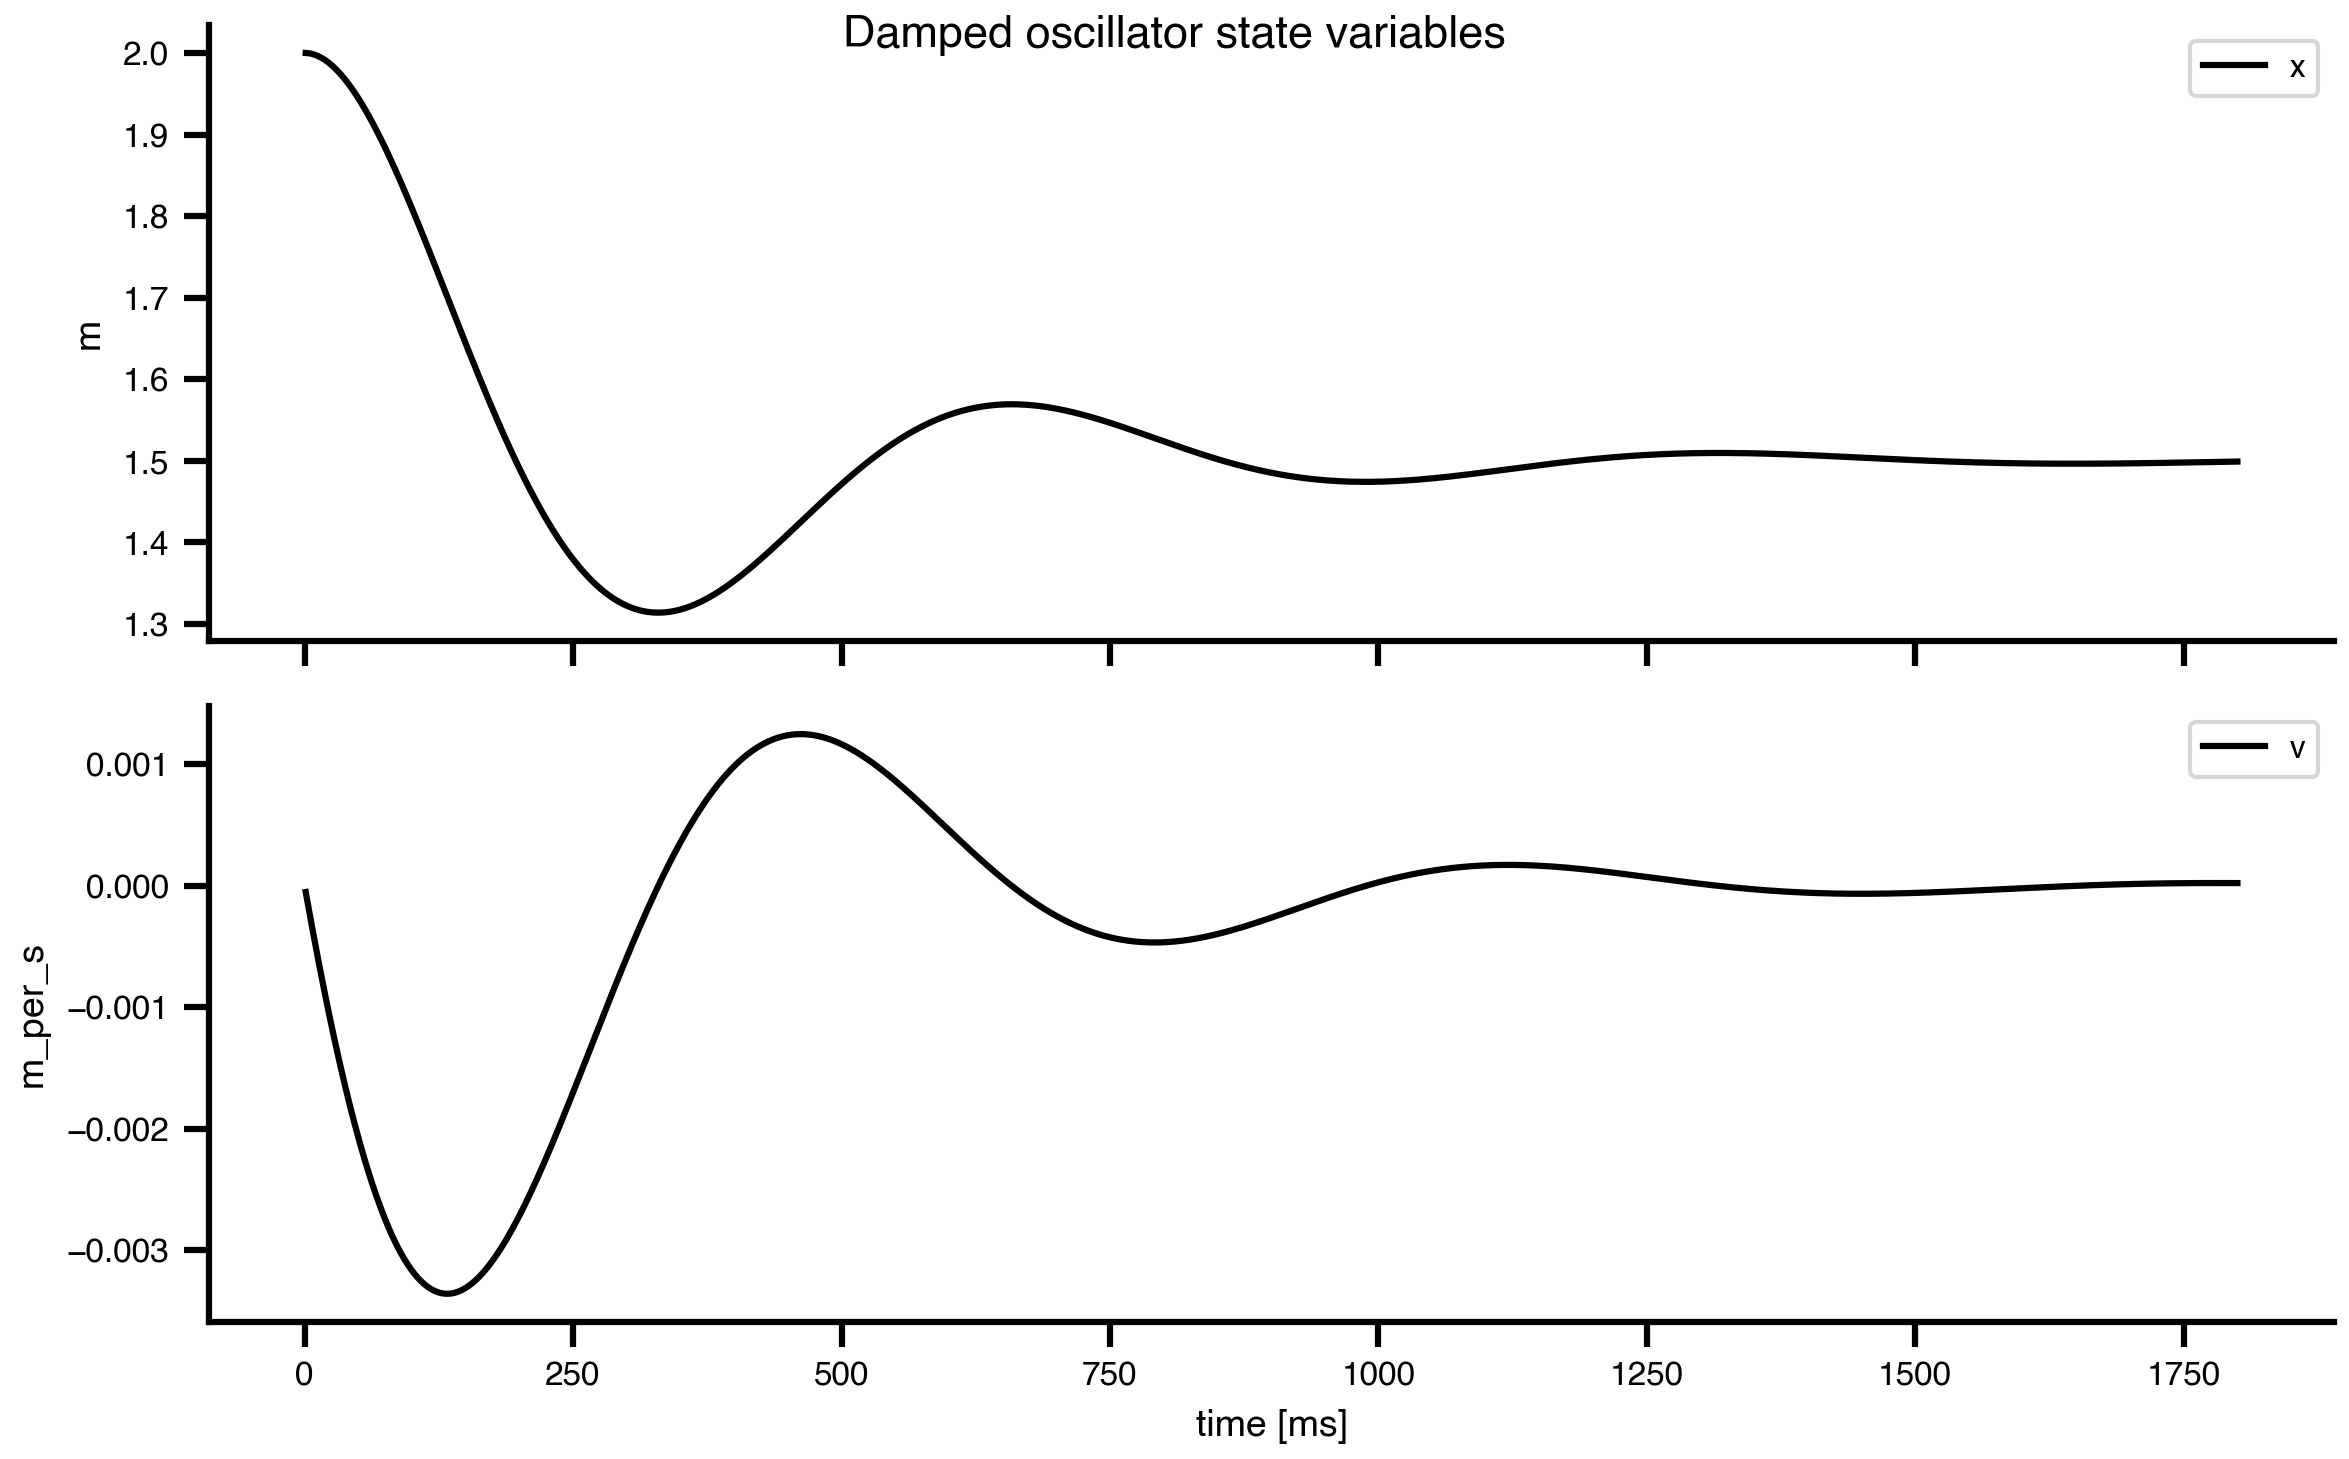

In [13]:
damped_experiment = SimulationExperiment(dynamics=damped_spring)
damped_experiment.integration.duration = 1800.0
damped_experiment.integration.step_size = 1.0

damped_result = damped_experiment.run("tvboptim")
fig = damped_result.integration.plot()
fig.suptitle("Damped oscillator state variables")
fig

In phase space, damping turns closed loops into spirals. The constant
load moves the final equilibrium to $x^* = m g_{\mathrm{eff}} / k$.

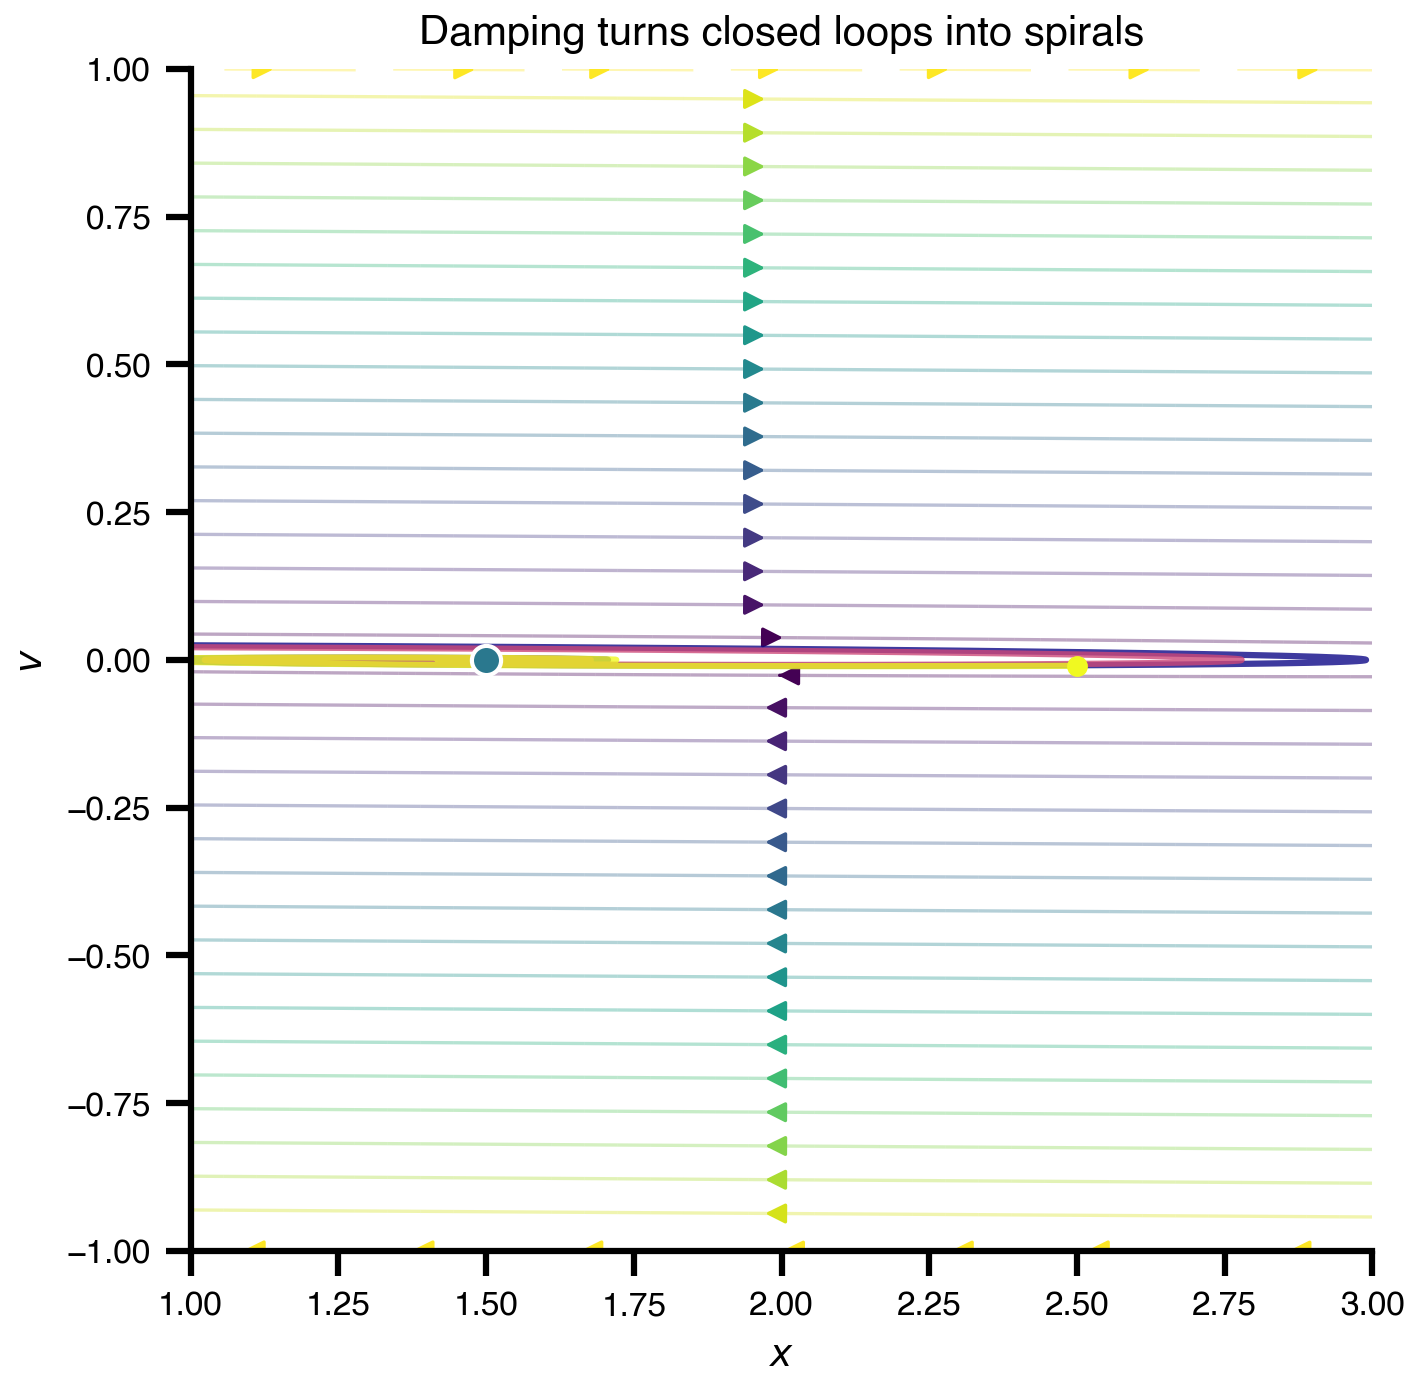

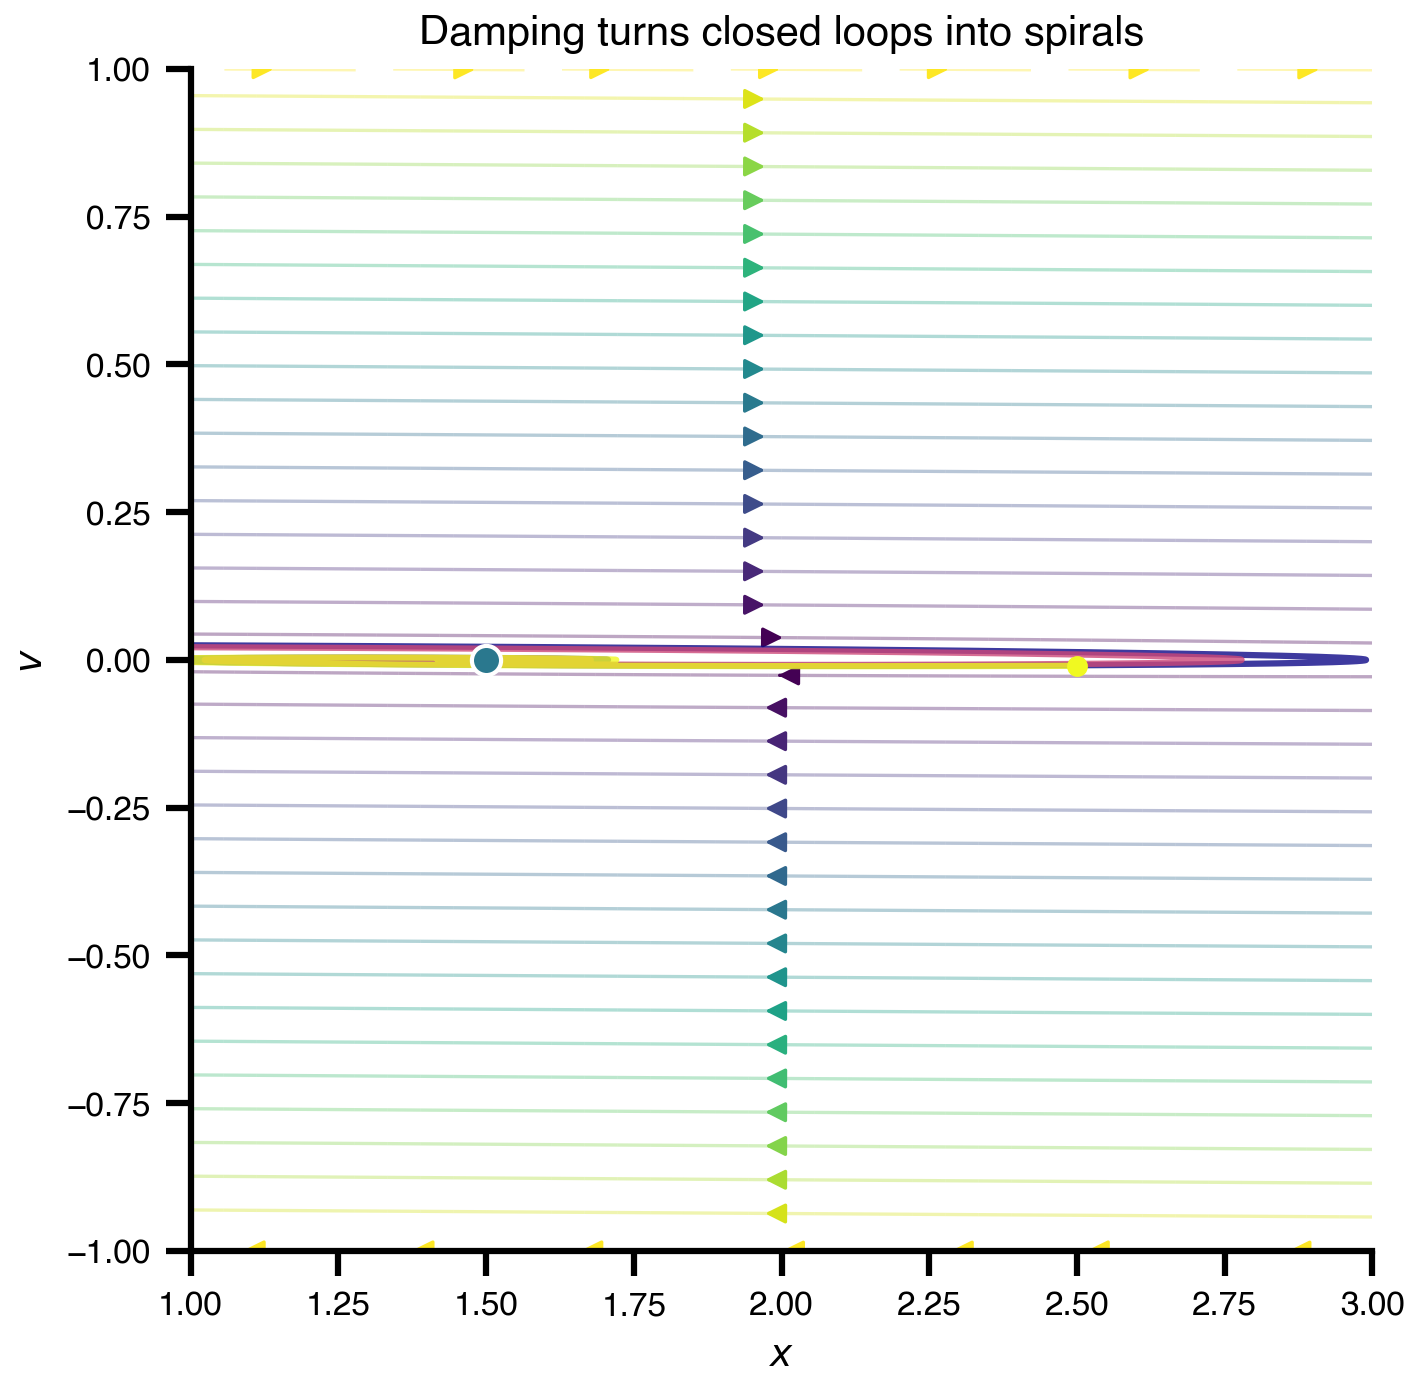

In [14]:
damped_initial_conditions = np.array([
    [-2.5, 0.0],
    [-1.5, 0.015],
    [2.5, -0.01],
])

fig, ax = plt.subplots(figsize=(5.2, 4.8))

damped_spring.plot("x", "v", kind="vectorfield", ax=ax, alpha=0.35, grid_n=24, stream=True)
damped_spring.plot(
    "x",
    "v",
    kind="phase",
    ax=ax,
    duration=1800.0,
    dt=1.0,
    n_trials=len(damped_initial_conditions),
    u_0=damped_initial_conditions,
    cmap="plasma",
    lw=1.5,
)

x_equilibrium = damped_spring.parameters["m"].value * damped_spring.parameters["g_eff"].value / damped_spring.parameters["k"].value
ax.plot(x_equilibrium, 0.0, "o", color="C3", ms=7, mec="white", mew=1.0, zorder=10)
ax.set_title("Damping turns closed loops into spirals")
fig.tight_layout()
fig

For a broader qualitative picture, let TVBO add sample trajectories on
top of the damped phase plane.

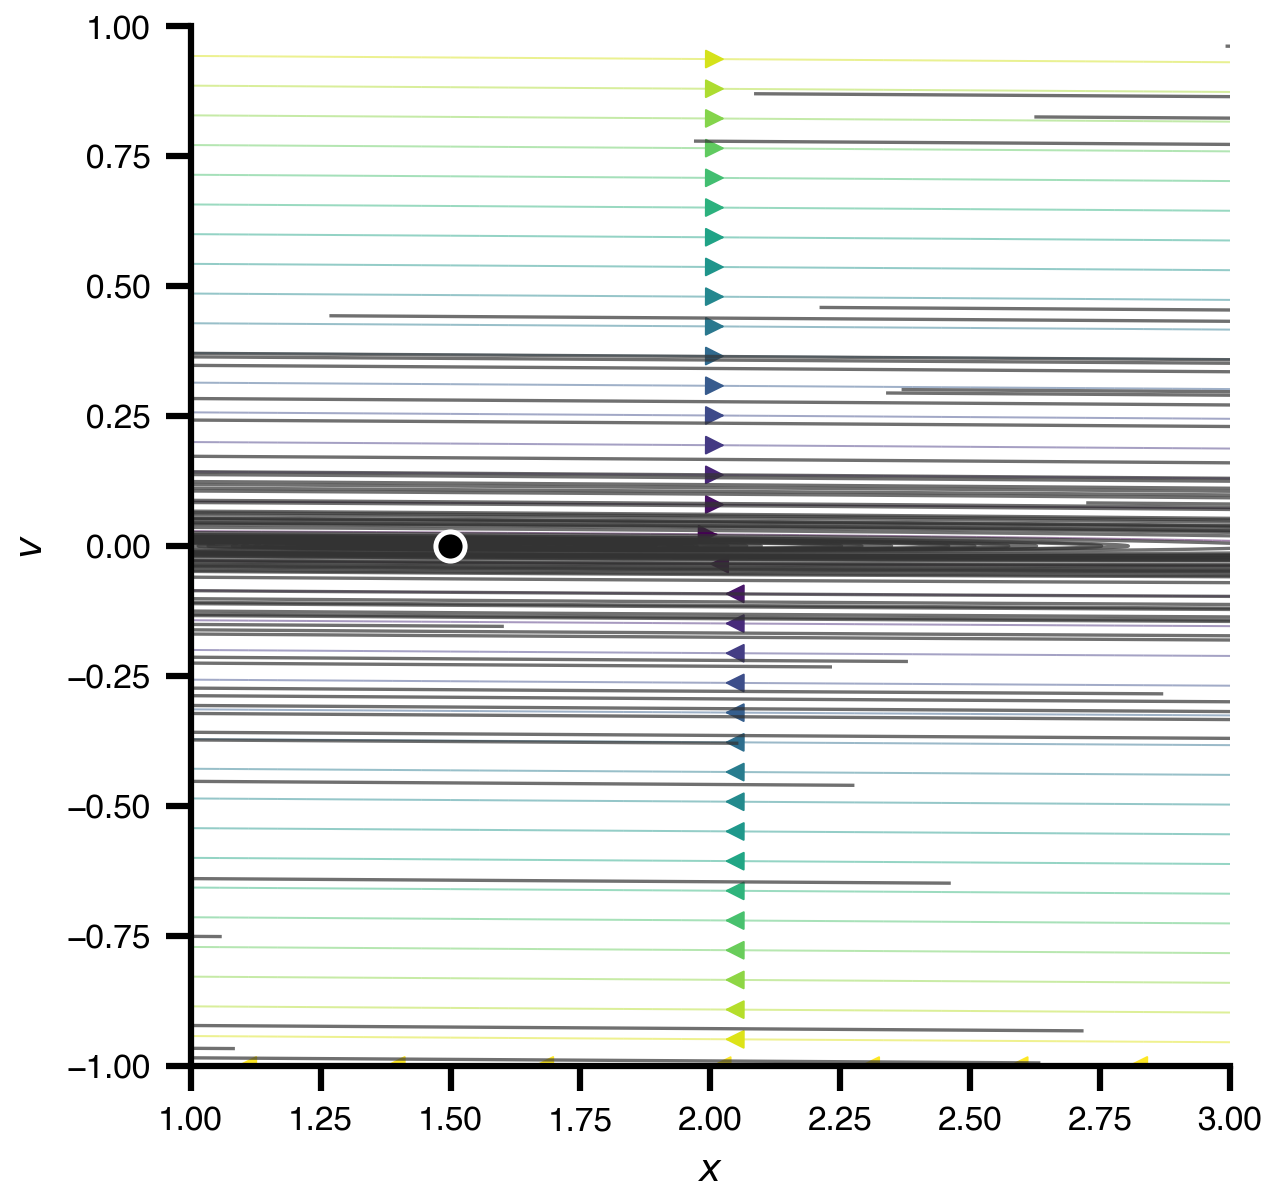

In [15]:
damped_spring.plot(
    "x",
    "v",
    kind="phaseplane",
    duration=1800.0,
    dt=1.0,
    n_trajectories=20,
    show_nullclines=False,
)

## Connection to TVBO Documentation

The spring example is intentionally simple, but each piece maps directly
to the main TVBO documentation topics.

| Concept in this notebook | TVBO object or method | Why it matters later |
|------------------------|------------------------|------------------------|
| Equations and parameters | `Dynamics` | Neural mass and oscillator models use the same schema. |
| Quick local simulation | `Dynamics.run()` | Fast checks of one isolated dynamical system. |
| Quick local plots | `Dynamics.plot()` | Time series, phase portraits, vector fields, and phase planes. |
| Full experiment execution | `SimulationExperiment.run("tvboptim")` | The experiment combines dynamics, integration, networks, observations, algorithms, and continuations. |
| Named output | `result.integration.data` | Results are xarray objects, so analysis should use named dimensions like `time`, `variable`, and `node`. |
| Parameter sweeps | `Exploration`, `ExplorationAxis` | Parameter scans become declarative experiment metadata. |
| Damping and load | Model specification | More realistic assumptions are added by changing equations and parameters, not by changing the execution workflow. |

## From Spring-Mass to Neural Mass Models

The next workshop section moves from a physical toy system to neural
mass models. The TVBO database already stores many such models with the
same structure: state variables, parameters, equations, and metadata.

In [16]:
neural_mass_models = Dynamics.list_db(model_type="neural_mass")
neural_mass_models[:8]

['CakanObermayer',
 'Epileptor3DStefanescuMcDonald',
 'GastSchmidtKnosche_SD',
 'GastSchmidtKnosche_SF',
 'Hopfield',
 'JansenRit',
 'JansenRit1995',
 'LarterBreakspear']

In [17]:
jansen_rit = Dynamics.from_db("JansenRit")
print("state variables:", list(jansen_rit.state_variables))
print("first parameters:", list(jansen_rit.parameters)[:8])

state variables: ['y0', 'y1', 'y2', 'y3', 'y4', 'y5']
first parameters: ['A', 'B', 'J', 'a_1', 'a_2', 'a_3', 'a_4', 'a']

This is the key bridge: the spring has $(x, v)$, while a neural mass
model has variables such as membrane potentials, firing-rate transforms,
or synaptic gating variables. But the TVBO workflow remains the same:

1.  Choose or define `Dynamics`.
2.  Put it in a `SimulationExperiment`.
3.  Run the experiment.
4.  Plot and analyze the result.

## What Comes Next in the Workshop

The spring notebook stops at a single deterministic system. The later
slides add the missing terms from the workshop equation.

| Next concept | TVBO object | Role |
|------------------------|------------------------|------------------------|
| Brain regions and structural connectivity | `Network` | Adds nodes, edges, weights, delays, and positions. |
| Inter-regional influence | `Coupling` | Turns source-node activity into input for target-node dynamics. |
| External stimulation or perturbations | `Event` | Adds time-dependent input $I_i(t)$. |
| Measurement models | `observations` | Transforms hidden state into BOLD, FC, PSD, or custom outputs. |
| Noise | noise terms and stochastic integrators | Adds fluctuations via $g(S_i, \theta^g)dW_i$. |
| Regime changes | `Continuation` | Tracks fixed points, stability changes, and oscillatory branches. |

This is why phase space and stability are introduced early. They are not
only mathematical background; they are the language used later to
interpret excitability, oscillations, bifurcations, and transitions in
neural population models.